In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

In [2]:
# define grids

r_perp = np.linspace(5, 140, 135+1)
r_los = np.linspace(5, 140, 135+1)

r_p = 0.5*(r_perp[1:]+r_perp[:-1])
r_l = 0.5*(r_los[1:]+r_los[:-1])


r_p_2d, r_l_2d = np.meshgrid(r_p, r_l, indexing='ij')
r = np.sqrt(r_p_2d**2 + r_l_2d**2)

mu = r_p_2d/r 

x = r * ( 1 - mu ) 
x2 = r - r_p

In [3]:
import os

def bin_pairwise_cat(raw_file_path, save_dir, R_bins, rlos_bins, M_bins):
    """
    Reads HDF5 galaxy catalog data, bins it by R and rlos, and saves the result.
    
    Parameters:
    - raw_file_path: str, path to the raw hdf5 file
    - save_dir: str, directory where the binned data should be saved
    - R_bins: array-like, the bin edges for R
    - rlos_bins: array-like, the bin edges for rlos
    
    Returns:
    - binned_dict: A nested dictionary structured as dict[R_bin_idx][rlos_bin_idx]['vpeclos']
    - master_df: The full Pandas DataFrame for advanced querying.
    """
    Mcens = (M_bins[:, 0]*M_bins[:, 1])**0.5  

    all_dfs = []
    
    # 1. Read and compile all data into a single DataFrame
    with h5.File(raw_file_path, 'r') as hdf:
        for k in range(len(Mcens)):
            # Load data for mass bin 'k'
            df = pd.DataFrame({
                'R': hdf[f'R/{k}'][()],
                'rlos': hdf[f'rlos/{k}'][()],
                'vpeclos': hdf[f'vpeclos/{k}'][()],
                'vr': hdf[f'vr/{k}'][()],
                'vphyslos': hdf[f'vphyslos/{k}'][()],
                'Mvir': Mcens[k]*np.ones(len(hdf[f'R/{k}'][()])) # assign same mass to all
            })

        
            # 2. Apply binning using pd.cut
            # labels=False returns integer indices for the bins
            df['M_bin'] = k #pd.cut(df['Mvir'], bins=M_bins, labels=False, include_lowest=True)
            df['R_bin'] = pd.cut(df['R'], bins=R_bins, labels=False, include_lowest=True)
            df['rlos_bin'] = pd.cut(df['rlos'], bins=rlos_bins, labels=False, include_lowest=True)
            
            # Drop data points that fall completely outside your defined bin edges
            df = df.dropna(subset=['M_bin', 'R_bin', 'rlos_bin']).copy()
            
            # Convert bin labels to integers
            df['M_bin'] = df['M_bin'].astype(int)
            df['R_bin'] = df['R_bin'].astype(int)
            df['rlos_bin'] = df['rlos_bin'].astype(int)
            
            all_dfs.append(df)
            
    # Combine everything
    master_df = pd.concat(all_dfs, ignore_index=True)
    
    # 3. Generate an indicative filename based on the bin inputs
    # Format: binned_R[len]_[min]-[max]_rlos[len]_[min]-[max].h5
    filename = (
        f"binned_"
        f"M{len(M_bins)-1}_{M_bins[0, 0]:.2e}-{M_bins[-1, -1]:.2e}_" 
        f"R{len(R_bins)-1}_{R_bins[0]:.1f}-{R_bins[-1]:.1f}_"
        f"rlos{len(rlos_bins)-1}_{rlos_bins[0]:.1f}-{rlos_bins[-1]:.1f}.h5"
    )
    save_path = os.path.join(save_dir, filename)
    
    # 4. Save the DataFrame to disk for easy retrieval later
    # Format 'table' allows for fast querying directly from the hard drive later if needed
    master_df.to_hdf(save_path, key='binned_data', mode='w', format='table')
    print(f"Successfully saved binned data to: {save_path}")
    
    # 5. Build a nested dictionary for immediate in-script analysis
    binned_dict = {}
    
    # Pandas groupby handles the 3D separation (R, rlos) in one fast sweep
    for (k, r_i, rlos_i), group in master_df.groupby(['M_bin', 'R_bin', 'rlos_bin']):
        if k not in binned_dict:
            binned_dict[k] = {}
        if r_i not in binned_dict[k]:
            binned_dict[k][r_i] = {}
            
        binned_dict[k][r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vr': group['vr'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
            'Mvir': group['Mvir'].values
        }
        
    return binned_dict, master_df


def load_pairwise_cat(file_path):
    """
    Loads binned HDF5 pair catalog data saved by bin_pairwise_cat.
    
    Parameters:
    - file_path: str, the exact path to the saved .h5 file
    
    Returns:
    - binned_dict: The reconstructed nested dictionary dict[R_bin_idx][rlos_bin_idx]
    - master_df: The full loaded Pandas DataFrame
    """
    # 1. Load the master DataFrame using the key we defined during saving
    master_df = pd.read_hdf(file_path, key='binned_data')
    
    # 2. Reconstruct the nested dictionary using the exact same groupby logic
    binned_dict = {}
    
    for (k, r_i, rlos_i), group in master_df.groupby(['M_bin', 'R_bin', 'rlos_bin']):
        if k not in binned_dict:
            binned_dict[k] = {}
        if r_i not in binned_dict[k]:
            binned_dict[k][r_i] = {}
            
        binned_dict[k][r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'vr': group['vr'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
            'Mvir': group['Mvir'].values
        }
        
    return binned_dict, master_df

In [5]:
# define paths to selections, save

cosmo_nums = np.array([0, 41, 53, 55, 66])

paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/{sim_num}/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_3massbins_SB250.hdf5' for sim_num in cosmo_nums]
save_paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/{sim_num}/data/' for sim_num in cosmo_nums]

# bin selections

# mass bins
log_edges = np.array([[13.2, 13.3], [13.5, 13.7], [14.1, 14.7]])
massbins = 10**log_edges

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dicts = []
master_dfs = []

for p_i, path in enumerate(paths):
    binned_dict, master_df = bin_pairwise_cat(path, save_paths[p_i], R_bins=r_perp, rlos_bins=r_los, M_bins=massbins)
    
    binned_dicts.append(binned_dict)
    master_dfs.append(master_df)

Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/fid_HR/0/data/binned_M2_1.58e+13-5.01e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5
Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/fid_HR/41/data/binned_M2_1.58e+13-5.01e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5
Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/fid_HR/53/data/binned_M2_1.58e+13-5.01e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5
Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/fid_HR/55/data/binned_M2_1.58e+13-5.01e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5
Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/fid_HR/66/data/binned_M2_1.58e+13-5.01e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5


In [ ]:
# load saved binned data

cosmo_nums = np.array([0, 41, 53, 55, 66])

paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/{sim_num}/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_3massbins_SB250.hdf5' for sim_num in cosmo_nums]
save_paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/{sim_num}/data/' for sim_num in cosmo_nums]

# bin selections

# mass bins
log_edges = np.array([[13.2, 13.3], [13.5, 13.7], [14.1, 14.7]])
massbins = 10**log_edges

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dicts = []
master_dfs = []

for p_i, path in enumerate(save_paths[:3]):
    binned_dict, master_df = load_pairwise_cat(path+'binned_M3_1.00e+13-7.94e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5')
    
    binned_dicts.append(binned_dict)
    master_dfs.append(master_df)

In [7]:
# compute mean radial velocity profiles <v_r|r, M> for each sim 

mean_vr_r_m_sims = np.full((len(cosmo_nums), len(M_cens), len(r_p)), np.nan)
mean_vr_r_m_sims_interps = np.empty((len(cosmo_nums), len(M_cens)), dtype=object)

for sim in range(len(cosmo_nums)):
    data_df = master_dfs[sim]

    data_df['r'] = np.sqrt(data_df['R']**2 + data_df['rlos']**2)
    data_df['r_bin'] = pd.cut(data_df['r'], bins=r_perp, labels=False, include_lowest=True)

    profile = (
        data_df.dropna(subset=['r_bin'])
        .groupby(['M_bin', 'r_bin'])['vr']
        .mean()
    )

    mean_vr_r_m = profile.unstack('r_bin').reindex(columns=range(len(r_p))).values

    mean_vr_r_m_sims[sim, :mean_vr_r_m.shape[0]] = mean_vr_r_m

    for k in range(mean_vr_r_m.shape[0]):
        y = mean_vr_r_m[k]
        mask = np.isfinite(y)
        if mask.sum() < 4:  # need enough points for k=5 spline; adjust threshold if needed
            mean_vr_r_m_sims_interps[sim, k] = None
            continue
        mean_vr_r_m_sims_interps[sim, k] = UnivariateSpline(r_p[mask], y[mask], s=0, k=5, ext=3)

In [9]:
# save 
os.makedirs(os.path.dirname('/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/'), exist_ok=True)
save_path = '/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/mean_vr_r_m_sims.hdf5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('mean_vr_r_m_sims', data=mean_vr_r_m_sims)
    #hdf.create_dataset('interps', data=mean_vr_r_m_sims_interps) 

    hdf.attrs['r_edges'] = r_perp
    hdf.attrs['M_edges'] = massbins

In [ ]:
# fit skew-t to P(v_pec|R, rlos, M) to each sim

from scipy.optimize import curve_fit

nus = 6

ST_pars = np.full((len(cosmo_nums), len(M_cens), len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)

for sim in range(len(cosmo_nums)):
    data_dict = binned_dicts[sim]
    for k in range(len(M_cens)):
        if k not in data_dict:
            continue  # empty mass bin — leave as nan

        mean_vr_interp = mean_vr_r_m_sims_interps[sim][k]

        for j in range(len(r_p)):
            if j not in data_dict[k]:
                continue

            for i in range(len(r_l)):
                if i not in data_dict[k][j]:
                    continue

                r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
                theta = np.arctan2(r_l[i], r_p[j])
                sin = np.sin(theta)

                peak = mean_vr_interp(r_3d) * sin

                width = np.std(data_dict[k][j][i]['vpeclos'])

                ve = np.linspace(peak-2500, peak+2500, 50+1)
                vc = 0.5*(ve[1:] + ve[:-1])

                hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)
                cent = 0.5*(edges[1:] + edges[:-1])

                if np.isnan(hist).any():
                    continue

                try:
                    p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                                  cent, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
                except RuntimeError:
                    continue
                
                ST_pars[sim, k, j, i] = p
                ST_errs[sim, k, j, i] = np.sqrt(np.diag(c))

In [12]:
# parallel version
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from tqdm import tqdm
from scipy.optimize import curve_fit

nus = 6

ST_pars = np.full((len(cosmo_nums), len(M_cens), len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)


def fit_sim_k(sim, k, data_dict, mean_vr_interp, r_p, r_l, nus):
    out = {}
    for j in range(len(r_p)):
        if j not in data_dict[k]:
            continue
        for i in range(len(r_l)):
            if i not in data_dict[k][j]:
                continue
            r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
            theta = np.arctan2(r_l[i], r_p[j])
            peak = mean_vr_interp(r_3d) * np.sin(theta)
            width = np.std(data_dict[k][j][i]['vpeclos'])

            ve = np.linspace(peak-2500, peak+2500, 51)
            vc = 0.5*(ve[1:] + ve[:-1])
            hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)

            if np.isnan(hist).any():
                continue
            try:
                p, c = curve_fit(
                    lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                    vc, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                continue
            out[(j, i)] = (p, np.sqrt(np.diag(c)))
    return sim, k, out

tasks = [(sim, k) for sim in range(len(cosmo_nums))
         for k in range(len(M_cens)) if k in binned_dicts[sim]]

with tqdm_joblib(tqdm(total=len(tasks), desc="Fitting skew-T")):
    results = Parallel(n_jobs=-1)(
        delayed(fit_sim_k)(sim, k, binned_dicts[sim], mean_vr_r_m_sims_interps[sim][k], r_p, r_l, nus)
        for sim, k in tasks
    )

for sim, k, out in results:
    for (j, i), (p, err) in out.items():
        ST_pars[sim, k, j, i] = p
        ST_errs[sim, k, j, i] = err

  0%|          | 0/15 [00:00<?, ?it/s]

Fitting skew-T:   0%|          | 0/15 [12:04<?, ?it/s]


In [70]:
# save 
save_path = '/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/ST_pars_nu6_meas_sigv.hdf5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('STpars', data=ST_pars)
    hdf.create_dataset('ST_errs', data=ST_errs)
    hdf.create_dataset('meas_sigv', data=meas_sigv)

    hdf.attrs['rperp_edges'] = r_perp
    hdf.attrs['rlos_edges'] = r_los
    hdf.attrs['M_edges'] = massbins
    hdf.attrs['nu'] = nus
    hdf.attrs['sim_sums'] = cosmo_nums 

In [14]:
def sigma_mod(x, sigma0, A_rho, sigma_rho):
    return np.sqrt(2 * sigma0**2 * (1 - A_rho * np.exp(-x / sigma_rho)))

def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)

In [68]:
meas_sigv.shape

(5, 3, 135, 135)

In [69]:
ST_pars.shape

(5, 3, 135, 135, 3)

In [15]:
# measure widths
meas_sigv = np.full((len(cosmo_nums), len(M_cens), len(r_p), len(r_l)), np.nan)

for sim in range(len(cosmo_nums)):
    data_dict = binned_dicts[sim]
    for k in range(len(M_cens)):

        if k not in data_dict:
            continue  # empty mass bin — leave as nan

        for j in range(len(r_p)):
            if j not in data_dict[k]:
                continue

            for i in range(len(r_l)):
                if i not in data_dict[k][j]:
                    continue
                
                std = np.std(data_dict[k][j][i]['vpeclos'])

                meas_sigv[sim, k, j, i] = std

In [17]:
# compute 1-D isotropic halo velocity dispersion for halos in sims. How different from one another, MDPL2?

# non-linear Pk instead 
import camb
from camb import model

sim_cosmo = [0.3175, 0.049, 0.6711, 0.9624, 0.834]

params = {'flat': True, 'H0': 100 * sim_cosmo[2], 'Om0': sim_cosmo[0], 'Ob0': sim_cosmo[1], 'sigma8': sim_cosmo[4], 'ns': sim_cosmo[3]}

cosmo = cosmology.setCosmology('myCosmo', params)

camb_params = [cosmo.H0, cosmo.Ombh2, cosmo.Omh2 - cosmo.Ombh2, cosmo.ns]

def get_sigma0_nl(params, redshift, kmax=10.0, npoints=500):

    pars = camb.set_params(H0=params[0], ombh2=params[1], omch2=params[2], ns=params[3])
    pars.set_matter_power(redshifts=[redshift], kmax=10.0) 
    pars.NonLinear = model.NonLinear_both

    results = camb.get_results(pars)
    kh_nl, z_nl, pk_nl = results.get_matter_power_spectrum(
        minkh=1e-4, maxkh=5.0, npoints=500
    )
    pk_nl = pk_nl[0] 

    h = params[0] / 100.0

    Om0 = (params[1] + params[2]) / h**2
    Omz = Om0 * (1.0 + redshift)**3 / (params[0] / (100.0 * h))**2
    f = Omz**0.55 # growth rate

    a = 1/(1+redshift)
    conv = a * params[0] / h

    sigma0_nl_sq = (f * conv)**2 / (6 * np.pi**2) * simpson(pk_nl, kh_nl)
    sigma0_nl = np.sqrt(sigma0_nl_sq)

    return sigma0_nl

    
sigma = get_sigma0_nl(camb_params, 0.0)
print(sigma)


356.709374292042


In [72]:
np.isnan(ST_pars[:, :, :, :, 2]).sum()/len(ST_pars[:, :, :, :, 2].flatten())

np.float64(1.0)

In [47]:
meas_sigv.shape

(5, 3, 135, 135)

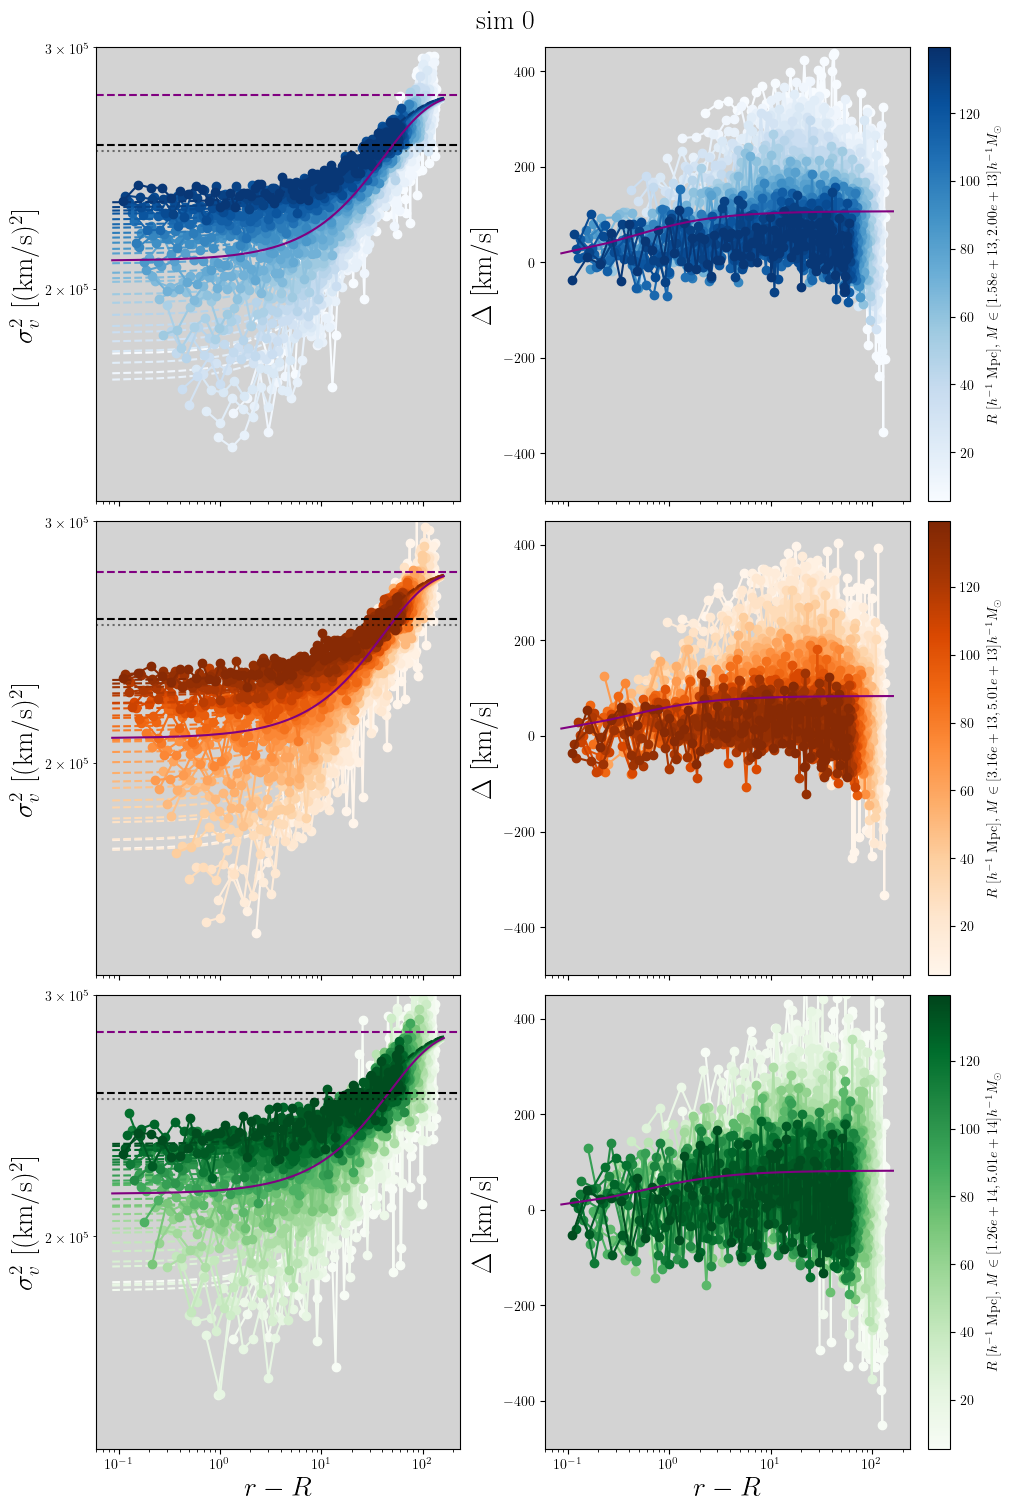

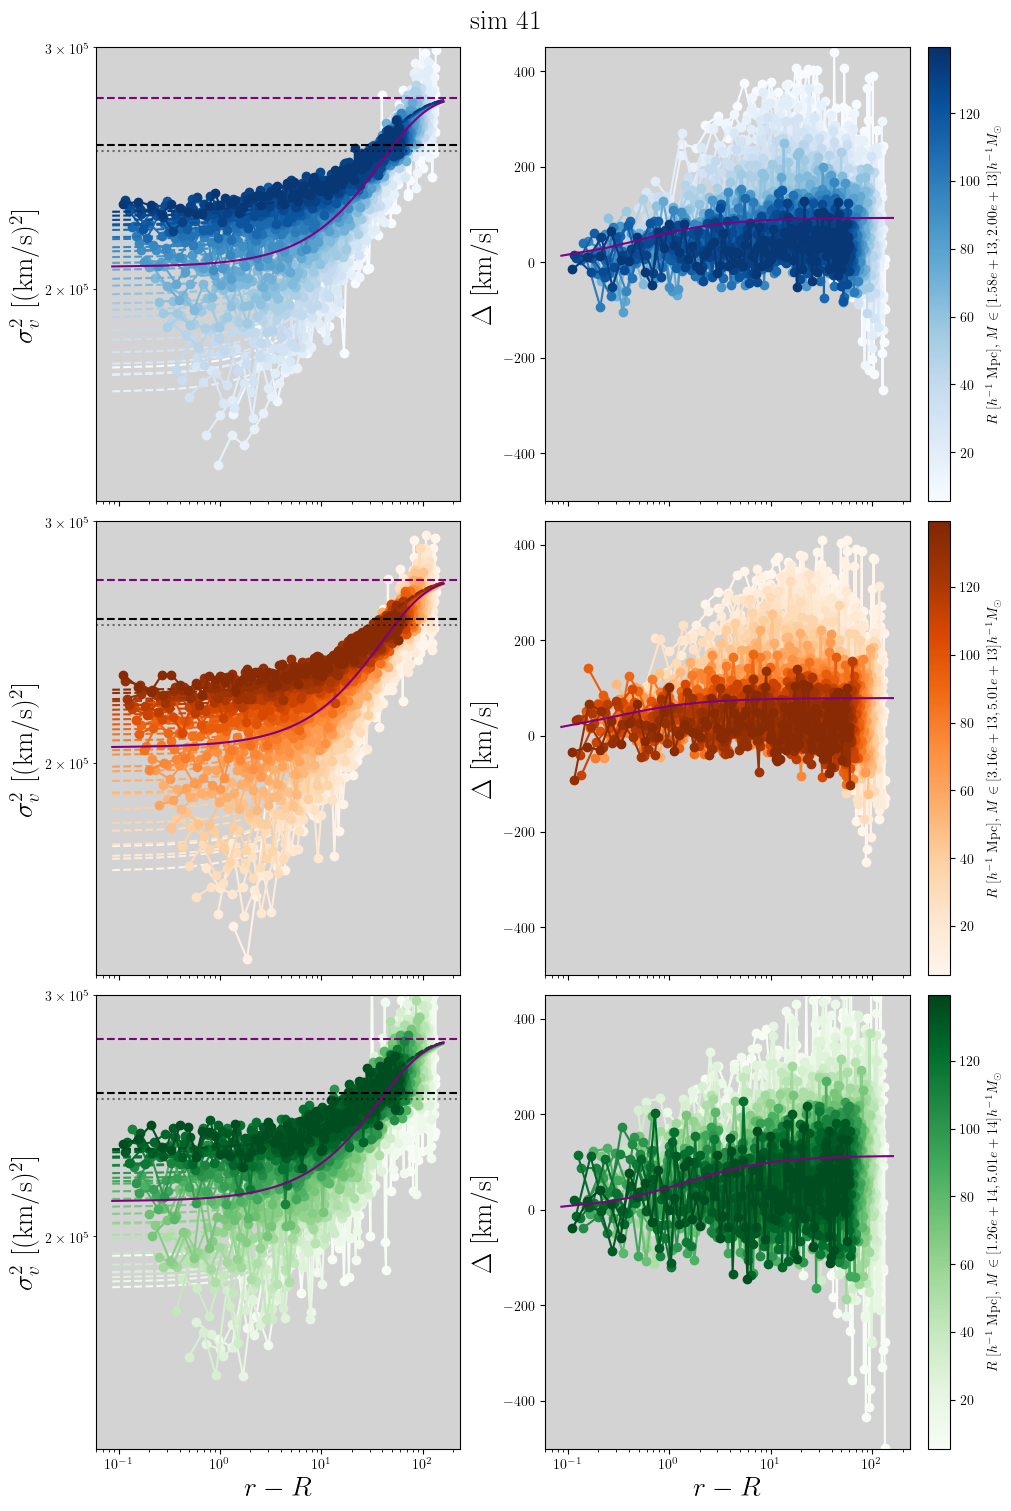

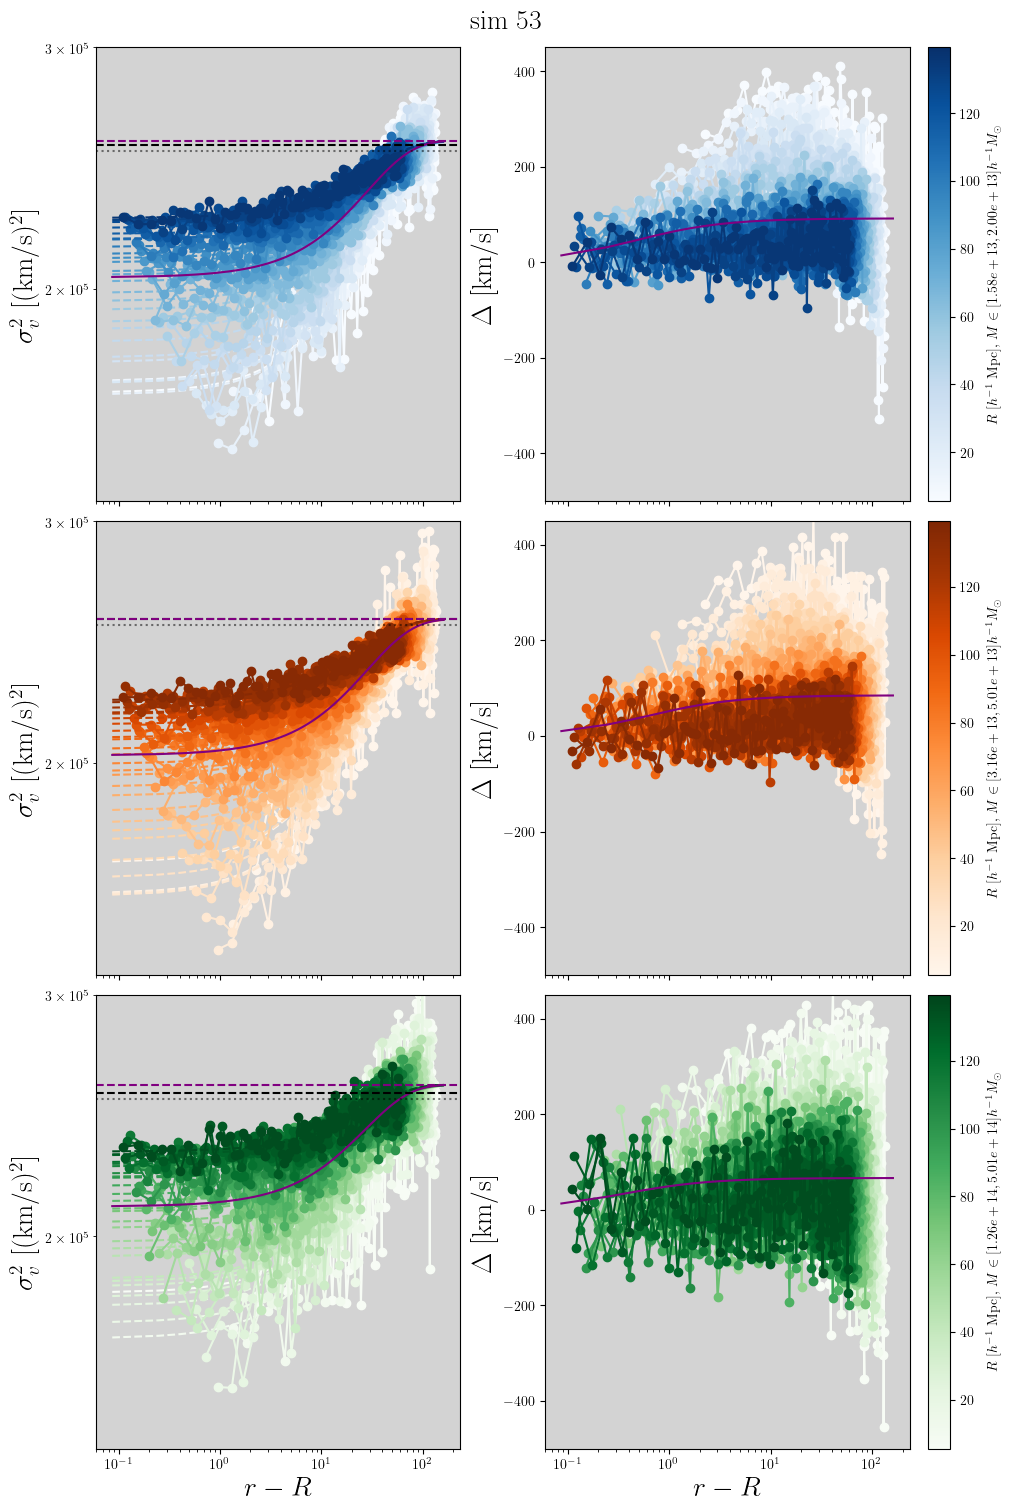

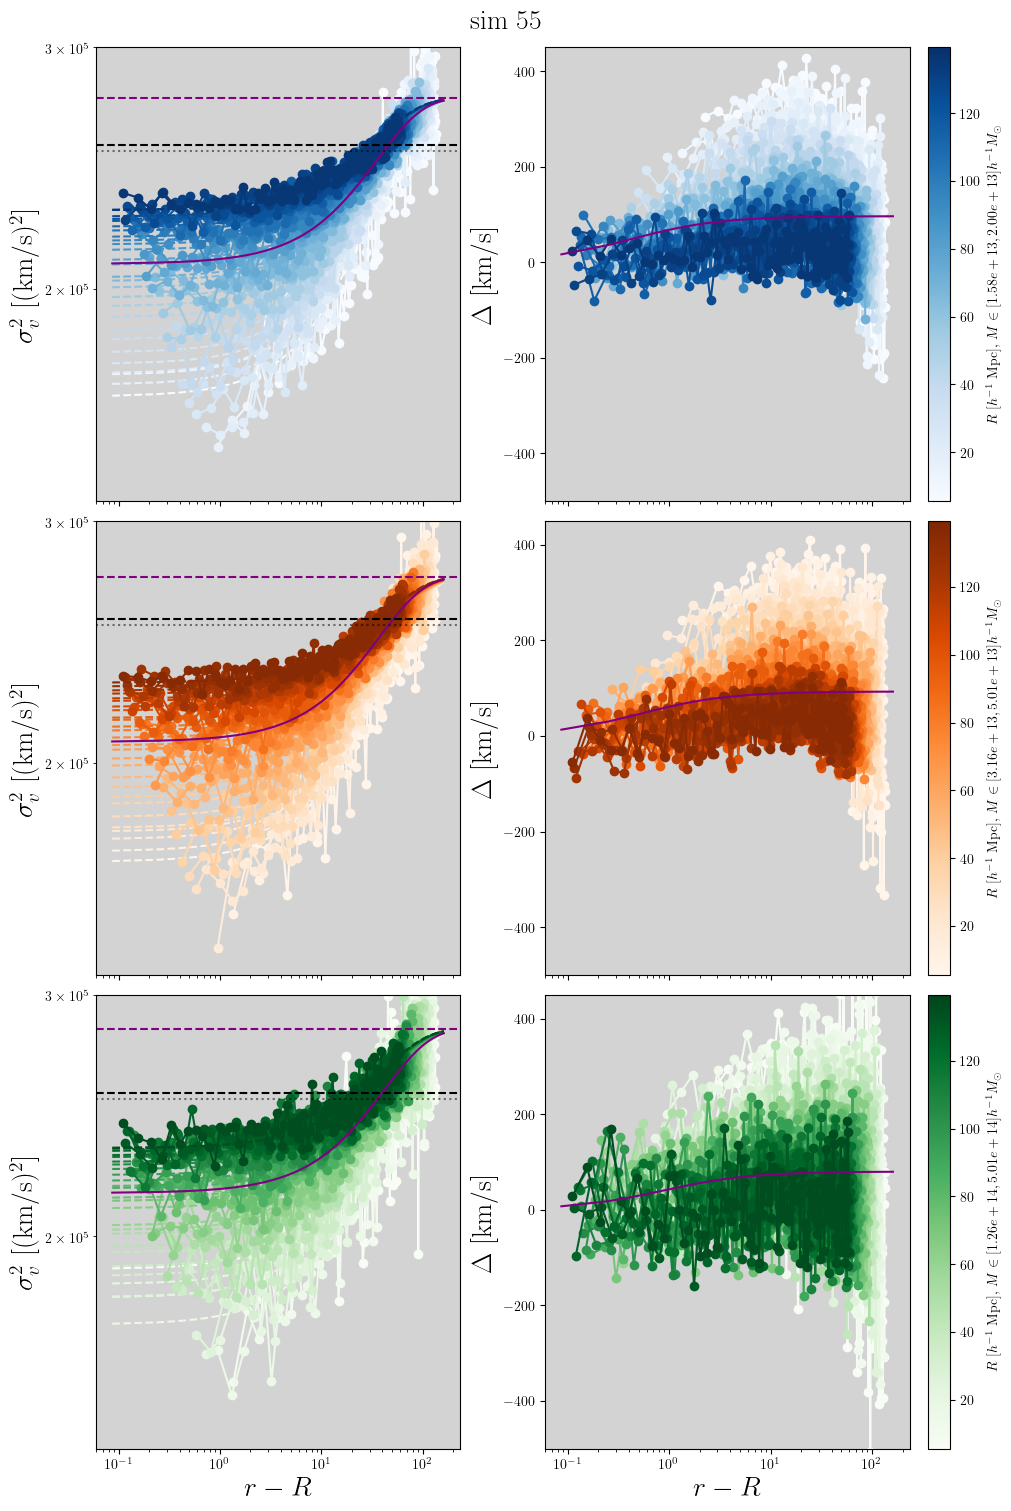

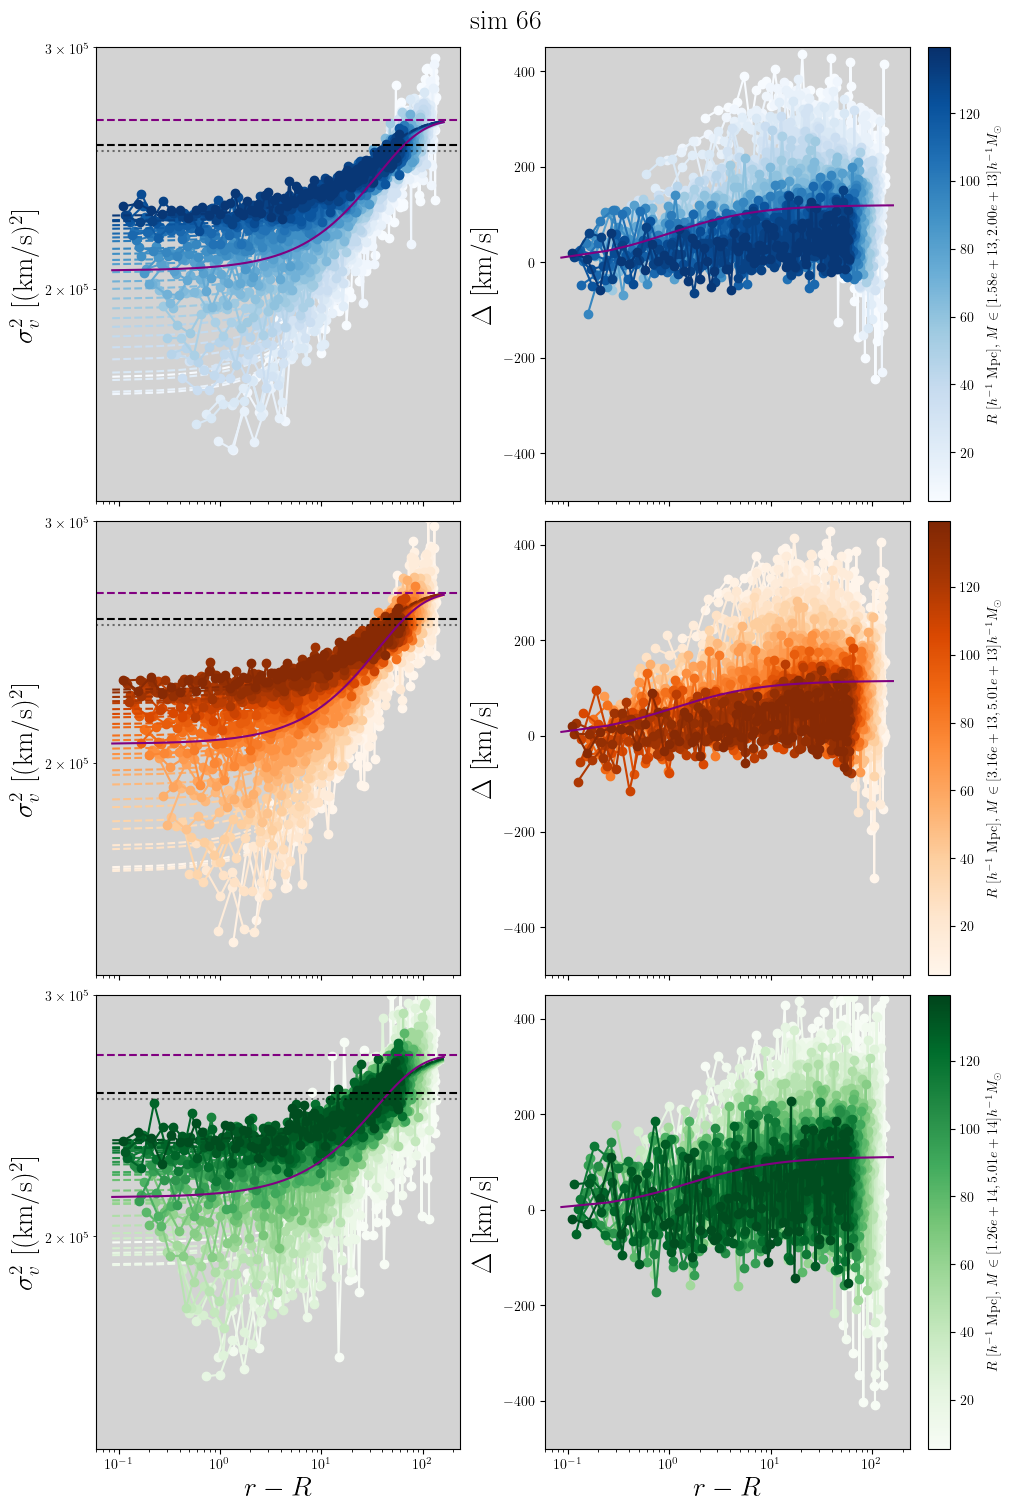

In [ ]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((len(cosmo_nums), len(M_cens), 3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((len(cosmo_nums), len(M_cens), 2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(cosmo_nums), len(M_cens), len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


sig_rho_fix = sig_opts[:, :, -1]


for sim in range(len(cosmo_nums)):
    fig, ax = plt.subplots(len(M_cens), 2, figsize=(10, 5*len(M_cens)), layout='constrained', sharex=True)

    fig.suptitle(rf"sim {cosmo_nums[sim]}", fontsize=20)

    for k in range(len(M_cens)):

        mean_vr_interp = mean_vr_r_m_sims_interps[sim][k]

        Delta = ST_pars[sim, k, :, :, 0] - mean_vr_interp(r) * r_l / r
        com_inputs = [meas_sigv[sim, k]**2, Delta]

        smask = np.isfinite(meas_sigv[sim, k].flatten()) & (meas_sigv[sim, k].flatten() > 0.1)
        dmask = np.isfinite(Delta.flatten()) & (Delta.flatten() > -1000)

        # fit models to each input 

        popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], (meas_sigv[sim, k]).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
        popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

        sig_opts[sim, k] = popt_sig
        sig_errs[sim, k] = np.sqrt(np.diag(sig_cov))
        del_opts[sim, k] = popt_del 
        del_errs[sim, k] = np.sqrt(np.diag(del_cov))


        xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

        for j in range(0, len(r_p), skip):
            for i in range(2):

                y = com_inputs[i][j, :]
                
                if i == 0:
                    mask = y > 0.1

                    if j == 0:
                        popt, pcov = curve_fit(lambda x, A, s: sigma_mod(x, sig_opts[sim, k, 0], A, s), x2[:, j], meas_sigv[sim, k, j, :], p0=popt_sig[1:], maxfev=5_000, absolute_sigma=True)
                        A_rho_R[sim, k, j//skip], sig_rho_fix = popt
                        A_rho_R_err[sim, k, j//skip] = np.sqrt(pcov[0, 0])

                        ax[k, i].plot(xs, sigma_mod(xs, sig_opts[sim, k, 0], *popt )**2, c=cmaps[k][j], ls='--')

                    else:
                        popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[sim, k, 0], A, sig_rho_fix), x2[:, j], meas_sigv[sim, k, j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

                        A_rho_R[sim, k, j//skip] = popt
                        A_rho_R_err[sim, k, j//skip] = np.sqrt(pcov)

                        ax[k, i].plot(xs, sigma_mod(xs, sig_opts[sim, k, 0], popt, sig_rho_fix )**2, c=cmaps[k][j], ls='--')

                if i == 1:
                    mask = y > -1000

                ax[k, i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[k][j])

                ax[k, i].set_facecolor('lightgray')
                
                ax[k, i].set_ylabel(names[i], fontsize=20)
                
                ax[k, i].set_xscale('log')
                
        norm = Normalize(vmin=min(r_p), vmax=max(r_p))
        sm = ScalarMappable(norm=norm, cmap=colormap_list[k])
        sm.set_array([])  # dummy array
        cbar = fig.colorbar(sm, ax=ax[k, -1])
        cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[k, 0]:.2e}, {massbins[k, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

        ax[k, 0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
        ax[k, 0].set_ylim((140_000, 300_000))
        ax[k, 0].set_xscale('log')
        ax[k, 0].axhline(2*(sigma)**2, c='k', ls='--')
        ax[k, 0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
        ax[k, 0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
        ax[k, 0].set_yscale('log')

        ax[-1, 0].set_xlabel(r'$r-R$', fontsize=20)
        ax[-1, 1].set_xlabel(r'$r-R$', fontsize=20)

        ax[k, 1].plot(xs, delta_mod(xs, *popt_del), c='purple')
        ax[k, 1].set_ylim((-500, 450))

In [27]:
del_opts.shape

(5, 3, 2)

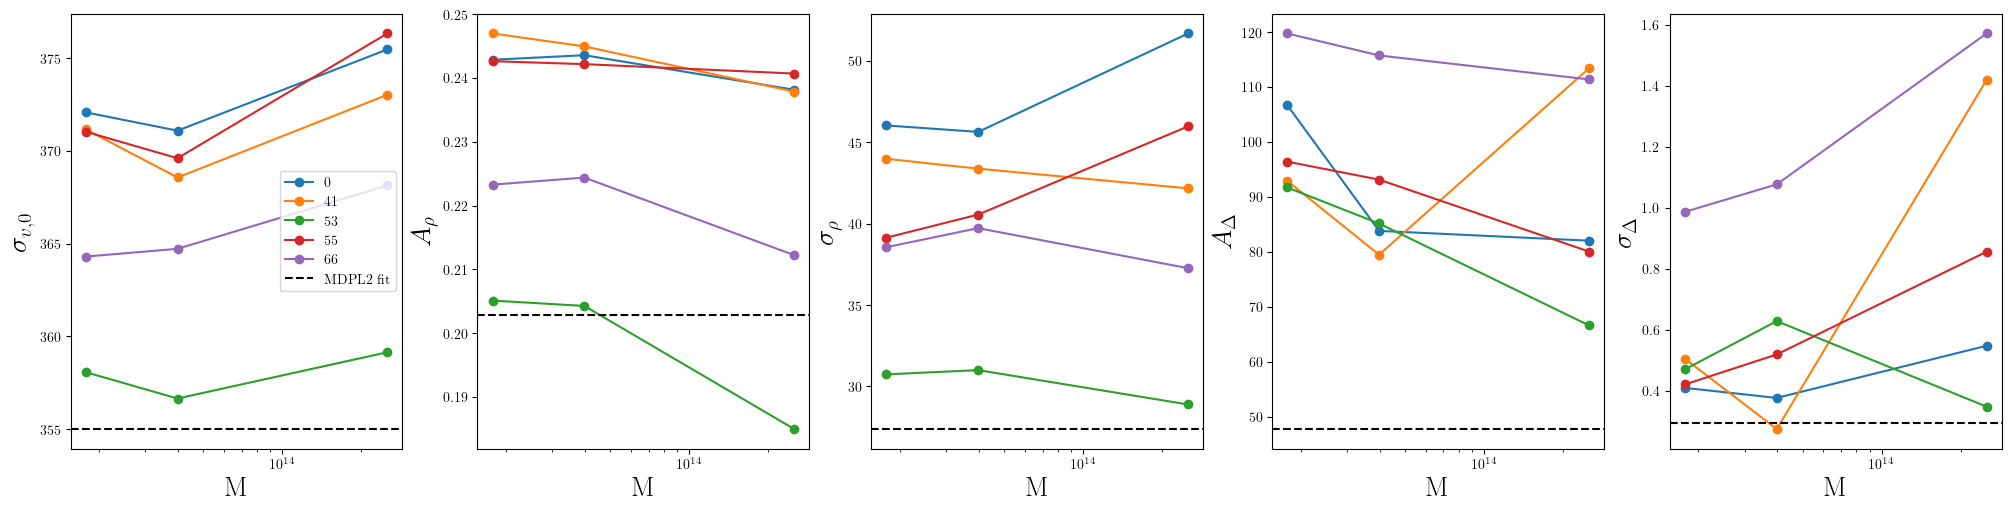

In [34]:
fig, ax = plt.subplots(1, 5, figsize=(20, 5), layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$", r"$A_\rho$", r"$\sigma_\rho$", r"$A_\Delta$", r"$\sigma_\Delta$"]

for i, label in enumerate(labels):
    for si, sim in enumerate(cosmo_nums):

        ax[i].plot(M_cens, parameters[si, :, i], marker='o', label=f"{sim}")
    
    ax[i].axhline(fixed_parameters[i], c='k', ls='--', label='MDPL2 fit')
    
    ax[i].set_ylabel(label)
    ax[i].set_xlabel(r'M')
    ax[i].set_xscale('log')

ax[0].legend()

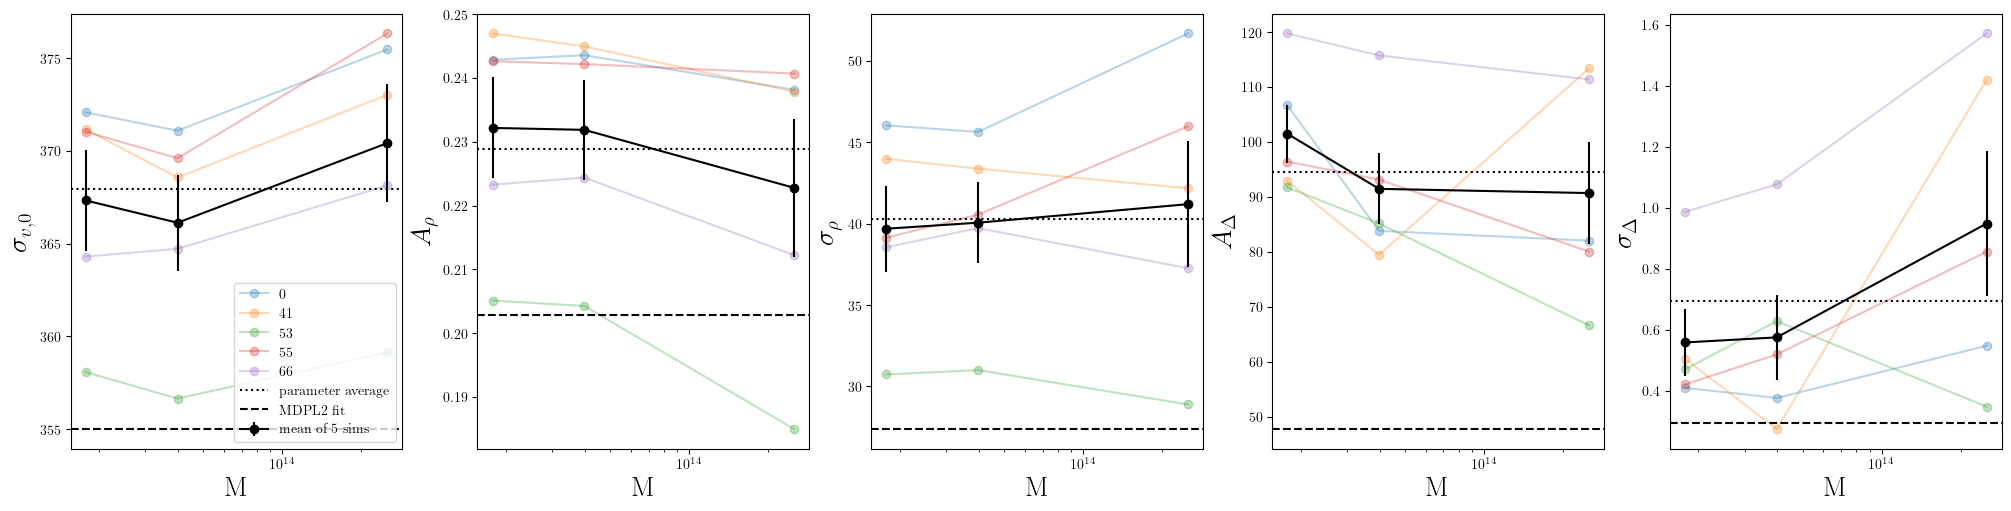

In [44]:
fig, ax = plt.subplots(1, 5, figsize=(20, 5), layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)  # (n_sims, n_mass, n_params)

labels = [r"$\sigma_{v, 0}$", r"$A_\rho$", r"$\sigma_\rho$", r"$A_\Delta$", r"$\sigma_\Delta$"]

n_sims = parameters.shape[0]

# leave-one-out jackknife across sims, vectorized
total = parameters.sum(axis=0)                        # (n_mass, n_params)
mean_vals = total / n_sims                             # (n_mass, n_params)
loo_means = (total - parameters) / (n_sims - 1)        # (n_sims, n_mass, n_params)
jack_err = np.sqrt((n_sims - 1) / n_sims * np.sum((loo_means - mean_vals) ** 2, axis=0))

for i, label in enumerate(labels):
    for si, sim in enumerate(cosmo_nums):
        ax[i].plot(M_cens, parameters[si, :, i], marker='o', label=f"{sim}", alpha=0.3)
    ax[i].errorbar(M_cens, mean_vals[:, i], yerr=jack_err[:, i], marker='o', color='k', label='mean of 5 sims')
    ax[i].axhline(np.mean(mean_vals[:, i]), c='k', ls=':', label='parameter average')
    ax[i].axhline(fixed_parameters[i], c='k', ls='--', label='MDPL2 fit')
    ax[i].set_ylabel(label)
    ax[i].set_xlabel(r'M')
    ax[i].set_xscale('log')

ax[0].legend()

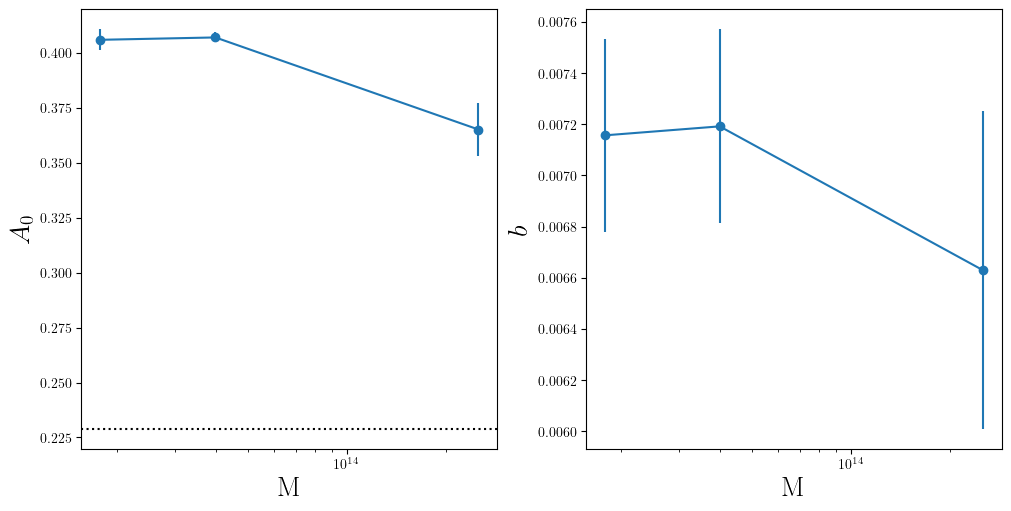

In [52]:

def exp_model(r_p, A_0, b):
    return A_0 * np.exp(-b * r_p)

n_sims, n_mass, n_rp = A_rho_R.shape

A_0_fit = np.zeros((n_sims, n_mass))
b_fit = np.zeros((n_sims, n_mass))

for si in range(n_sims):
    for mi in range(n_mass):
        y = A_rho_R[si, mi]
        p0 = [y[0], 0.1]
        popt, _ = curve_fit(exp_model, r_p[::5], y, p0=p0)
        A_0_fit[si, mi], b_fit[si, mi] = popt

# jackknife (leave-one-sim-out) over sims, vectorized, same as before
def jackknife_mean_err(x):
    # x: (n_sims, n_mass)
    total = x.sum(axis=0)
    mean_vals = total / n_sims
    loo_means = (total - x) / (n_sims - 1)
    err = np.sqrt((n_sims - 1) / n_sims * np.sum((loo_means - mean_vals) ** 2, axis=0))
    return mean_vals, err

A_0_mean, A_0_err = jackknife_mean_err(A_0_fit)
b_mean, b_err = jackknife_mean_err(b_fit)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

ax[0].errorbar(M_cens, A_0_mean, yerr=A_0_err, marker='o')
ax[0].axhline(np.mean(mean_vals[:, 1]), c='k', ls=':')
ax[0].set_ylabel(r"$A_0$")
ax[0].set_xlabel(r'M')
ax[0].set_xscale('log')

ax[1].errorbar(M_cens, b_mean, yerr=b_err, marker='o')
ax[1].set_ylabel(r"$b$")
ax[1].set_xlabel(r'M')
ax[1].set_xscale('log')

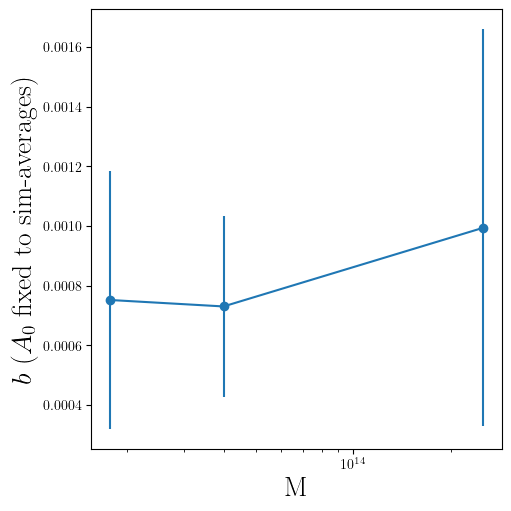

In [58]:
A_rho_M_mean = mean_vals[:, 1]  # from the first snippet, (n_mass,), A_rho averaged over sims

def exp_model_fixed_A0(r_p, b, A_0):
    return A_0 * np.exp(-b * r_p)

b_fit_fixedA0 = np.zeros((n_sims, n_mass))

for si in range(n_sims):
    for mi in range(n_mass):
        y = A_rho_R[si, mi]
        A_0 = A_rho_M_mean[mi]
        popt, _ = curve_fit(lambda r_p, b: exp_model_fixed_A0(r_p, b, A_0), r_p[::5], y, p0=[0.1])
        b_fit_fixedA0[si, mi] = popt[0]

b_fixedA0_mean, b_fixedA0_err = jackknife_mean_err(b_fit_fixedA0)

fig, ax = plt.subplots(figsize=(5, 5), layout='constrained')
ax.errorbar(M_cens, b_fixedA0_mean, yerr=b_fixedA0_err, marker='o')
ax.set_ylabel(r"$b$ ($A_0$ fixed to sim-averages)")
ax.set_xlabel(r'M')
ax.set_xscale('log')

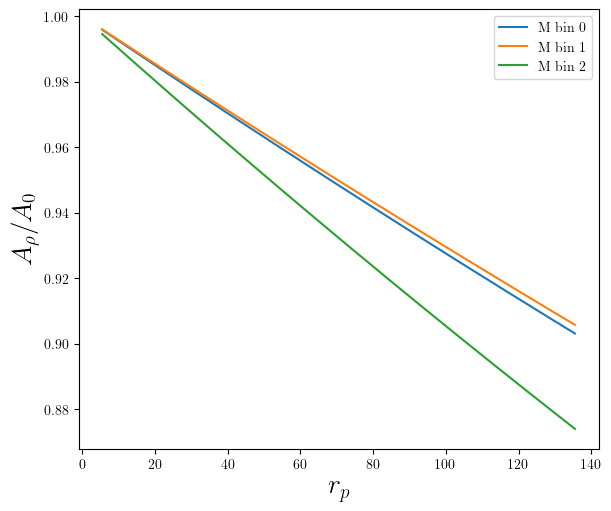

In [57]:
r_p_grid = np.linspace(r_p[::skip].min(), r_p[::skip].max(), 200)

fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')

for mi in range(n_mass):
    ratio = np.exp(-b_fixedA0_mean[mi] * r_p_grid)
    ax.plot(r_p_grid, ratio, label=f"M bin {mi}")

ax.set_ylabel(r"$A_\rho / A_0$")
ax.set_xlabel(r"$r_p$")
ax.legend()

In [67]:
b_fixedA0_mean

array([0.00075198, 0.00073035, 0.00099373])